
##**Exercise:**
1.   Load heart disease dataset in pandas dataframe
2.   Remove outliers using Z score. Usual guideline is to remove anything that has Z score > 3 formula or Z score < -3
3. Convert text columns to numbers using label encoding and one hot encoding
4. Apply scaling
5. Build a classification model using various methods (SVM, logistic regression, random forest) and check which model gives you the best accuracy
6. Now use PCA to reduce dimensions, retrain your model and see what impact it has on your model in terms of accuracy. Keep in mind that many times doing PCA reduces the accuracy but computation is much lighter and that's the trade off you need to consider while building models in real life



In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [132]:
df= pd.read_csv("/content/heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [134]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [135]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [136]:
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
classes={}
for i in ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']:
  df[i]= le.fit_transform(df[i])
  classes[i]= le.classes_

In [137]:
dir(le)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_build_request_for_signature',
 '_check_feature_names',
 '_check_n_features',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_tags',
 '_more_tags',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_sklearn_auto_wrap_output_keys',
 '_validate_data',
 '_validate_params',
 'classes_',
 'fit',
 'fit_transform',
 'get_metadata_routing',
 'get_params',
 'inverse_transform',
 'set_output',
 'set_params',
 'transfor

In [138]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


In [139]:
classes

{'Sex': array(['F', 'M'], dtype=object),
 'ChestPainType': array(['ASY', 'ATA', 'NAP', 'TA'], dtype=object),
 'RestingECG': array(['LVH', 'Normal', 'ST'], dtype=object),
 'ExerciseAngina': array(['N', 'Y'], dtype=object),
 'ST_Slope': array(['Down', 'Flat', 'Up'], dtype=object)}

In [140]:
for i in df:
  z_scores = (df - df.mean()) / df.std()
  cleaned_df = df[~(np.abs(z_scores) >= 3).any(axis=1)]

In [141]:
cleaned_df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


{'whiskers': [<matplotlib.lines.Line2D at 0x7b0508673d70>,
 'caps': [<matplotlib.lines.Line2D at 0x7b050869c350>,
 'boxes': [<matplotlib.lines.Line2D at 0x7b0508673a10>],
 'medians': [<matplotlib.lines.Line2D at 0x7b050869c8f0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7b050869cc20>],
 'means': []}

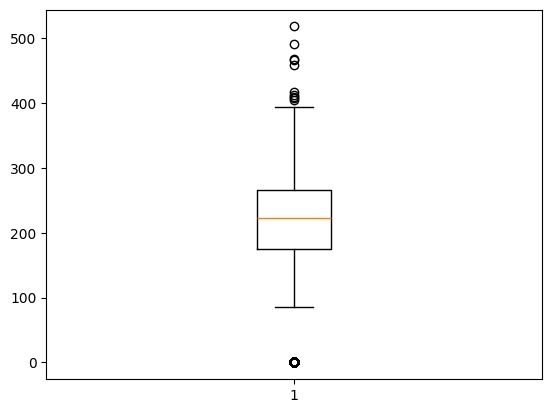

In [142]:
plt.boxplot(cleaned_df['Cholesterol'])

In [143]:
df.shape

(918, 12)

In [144]:
cleaned_df.shape

(899, 12)

In [145]:
target= cleaned_df['HeartDisease']
target.head()

,HeartDisease
0,0
1,1
2,0
3,1
4,0


In [146]:
cleaned_df= cleaned_df.drop(['HeartDisease'],axis=1)
cleaned_df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,1,1,140,289,0,1,172,0,0.0,2
1,49,0,2,160,180,0,1,156,0,1.0,1
2,37,1,1,130,283,0,2,98,0,0.0,2
3,48,0,0,138,214,0,1,108,1,1.5,1
4,54,1,2,150,195,0,1,122,0,0.0,2


In [147]:
from sklearn.preprocessing import MinMaxScaler
mn= MinMaxScaler()

In [148]:
X= np.array(cleaned_df)

In [149]:
X_scaled= mn.fit_transform(cleaned_df)

In [150]:
X_scaled

array([[0.24489796, 1.        , 0.33333333, ..., 0.        , 0.33333333,
        1.        ],
       [0.42857143, 0.        , 0.66666667, ..., 0.        , 0.5       ,
        0.5       ],
       [0.18367347, 1.        , 0.33333333, ..., 0.        , 0.33333333,
        1.        ],
       ...,
       [0.59183673, 1.        , 0.        , ..., 1.        , 0.53333333,
        0.5       ],
       [0.59183673, 0.        , 0.33333333, ..., 0.        , 0.33333333,
        0.5       ],
       [0.20408163, 1.        , 0.66666667, ..., 0.        , 0.33333333,
        1.        ]])

In [151]:
len(X_scaled)

899

In [152]:
len(target)

899

In [153]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [154]:
model_params={


    'Randomforest':{
        'model':RandomForestClassifier(),
        'params': {
            'n_estimators':[100,300,500]
        }
    },

    'logisticregression':{
        'model': LogisticRegression(solver='liblinear'),
        'params':{'C':[1, 10, 12]}
    },
    'svm':{
        'model':SVC(gamma='auto'),
        'params':{
            'C':[1,10,20]
        }
    }

}

In [155]:
score= []
for mn,mp in model_params.items():
  clf=GridSearchCV(mp['model'],mp['params'],cv=5,return_train_score=False)
  clf.fit(X,target)
  score.append({
      'model':mn,
      'best_params':clf.best_params_,
      'best_score':clf.best_score_
  })

In [156]:
best_model= pd.DataFrame(score,columns=['model','best_params','best_score'])
best_model

,model,best_params,best_score
0,Randomforest,{'n_estimators': 500},0.824165
1,logisticregression,{'C': 10},0.804159
2,svm,{'C': 10},0.561732


In [157]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,target,test_size=0.2)

In [158]:
model= RandomForestClassifier(n_estimators=400)

In [159]:
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=400)

In [160]:
model.score(X_test,y_test)

0.9055555555555556

##After PCA


In [167]:
from sklearn.decomposition import PCA
pca= PCA(0.95)
X_pca= pca.fit_transform(X_scaled)

In [168]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, target, test_size=0.2, random_state=30)

In [169]:
X_train.shape

(719, 11)

In [170]:
X_train_pca.shape

(719, 9)

In [171]:
model.fit(X_train_pca,y_train_pca)

RandomForestClassifier(n_estimators=400)

In [172]:
model.score(X_test_pca,y_test_pca)

0.8277777777777777